In [104]:
df = pd.read_csv("social_media_engagement_5000.csv")

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [106]:
df.duplicated().sum()

np.int64(0)

In [107]:
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [109]:
df = pd.read_csv("social_media_engagement_5000.csv")

In [110]:
df['posted_at'] = pd.to_datetime(df['posted_at'], format='%d-%m-%Y')

In [111]:
df['posted_at'].dtype

dtype('<M8[ns]')

In [112]:
likes_array = np.array(df['likes'].dropna())

print("First 10 likes values:")
print(likes_array[:10])

print("Average likes:")
print(np.mean(likes_array))

First 10 likes values:
[ 7011. 11750.  4862.  5350. 12682. 12535. 11703.  9611. 14106.   355.]
Average likes:
10107.043711340206


Data Cleaning

In [113]:
#Handling Misiing numerical values
df['age'] = df['age'].fillna(df['age'].median())

df['likes'] = df['likes'].fillna(df['likes'].median())

df['comments'] = df['comments'].fillna(df['comments'].median())

df['shares'] = df['shares'].fillna(df['shares'].median())


In [114]:
#Handling missing categorical values
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])

In [115]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [116]:
df.duplicated().sum()

np.int64(0)

Data formating


In [117]:
#Categorical values
print("Gender:")
print(df['gender'].unique())

print("\nPost Type:")
print(df['post_type'].unique())

print("\nPost Category:")
print(df['post_category'].unique())

print("\nSentiment:")
print(df['sentiment'].unique())

print("\nDevice Type:")
print(df['device_type'].unique())

Gender:
['Female' 'Male' 'Other']

Post Type:
['image' 'reel' 'text' 'video']

Post Category:
['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']

Sentiment:
['negative' 'positive' 'neutral']

Device Type:
['mobile' 'tablet' 'desktop']


In [118]:
#Numerical Values
df[['age', 'likes', 'comments', 'shares']].describe()

,age,likes,comments,shares
count,5000.000000,5000.000000,5000.000000,5000.0000
mean,38.440400,10106.997400,1502.039800,1002.9106
std,14.687151,5702.293017,856.393312,570.8552
min,13.000000,10.000000,0.000000,0.0000
25%,26.000000,5235.000000,792.000000,511.0000
50%,38.000000,10105.500000,1497.000000,1012.0000
75%,51.000000,14959.000000,2235.250000,1483.0000
max,64.000000,19998.000000,2999.000000,1999.0000


In [119]:
#Check for negative engagement values
print("Negative likes:", (df['likes'] < 0).sum())
print("Negative comments:", (df['comments'] < 0).sum())
print("Negative shares:", (df['shares'] < 0).sum())

Negative likes: 0
Negative comments: 0
Negative shares: 0


In [120]:
#Feature Cleaning
df['hashtags'].head(10)

,hashtags
0,#foodie #travel #love
1,#fitness
2,#foodie
3,#music #foodie #fun
4,#travel
5,#fitness
6,#music
7,#travel #music #fitness
8,#music #fun #fitness
9,#lifestyle #love


In [121]:
#Create Hashtag Count
df['hashtag_count'] = df['hashtags'].str.split().str.len()

In [122]:
df['hashtag_count'] = df['hashtags'].str.count('#')

In [123]:
df[['hashtags', 'hashtag_count']].head(10)

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1
5,#fitness,1
6,#music,1
7,#travel #music #fitness,3
8,#music #fun #fitness,3
9,#lifestyle #love,2


Clean Sentiment Labels

In [124]:
df['sentiment'].value_counts()

,count
sentiment,
positive,2513
neutral,1527
negative,960


In [125]:
df['sentiment'].unique()

array(['negative', 'positive', 'neutral'], dtype=object)

In [126]:
df['sentiment'] = df['sentiment'].str.strip().str.lower()

In [127]:
df['sentiment'].unique()

array(['negative', 'positive', 'neutral'], dtype=object)

In [128]:
df['sentiment'].isnull().sum()

np.int64(0)



3 — Data Exploration Using Pandas

In [129]:
#View the first and last rows
print("First 5 rows:")
df.head()

First 5 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [130]:
print("Last 5 rows:")
df.tail()

Last 5 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [131]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [132]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [133]:
#Check dataset dimesnsions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 5000
Number of columns: 20


In [134]:
# Display column names

df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [135]:
# Check Data Types

df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [136]:
# Generate Summary statistics

df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [137]:
# Analyse Categorical Variables

df['post_type'].value_counts()

,count
post_type,
reel,1283
image,1247
text,1245
video,1225


In [138]:
df['post_category'].value_counts()

,count
post_category,
fitness,675
tech,665
music,635
education,631
lifestyle,607
travel,600
fashion,594
food,593


In [139]:
df['sentiment'].value_counts()

,count
sentiment,
positive,2513
neutral,1527
negative,960


In [140]:
df['gender'].value_counts()

,count
gender,
Male,1849
Other,1581
Female,1570


In [141]:
# 3.7 unique() and nunique()

print("Post types:")
print(df['post_type'].unique())

print("\nNumber of post types:")
print(df['post_type'].nunique())

Post types:
['image' 'reel' 'text' 'video']

Number of post types:
4


Correlation Matrix


In [142]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,0.004058,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,-0.000079,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.025208,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,-0.016200,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,-0.012398,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.007025,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,0.012326,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,0.008317,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,-0.017808,0.002292,0.008802
is_verified,0.004058,-0.000079,0.025208,-0.016200,-0.012398,0.007025,0.012326,0.008317,-0.017808,1.000000,0.005528,0.001396


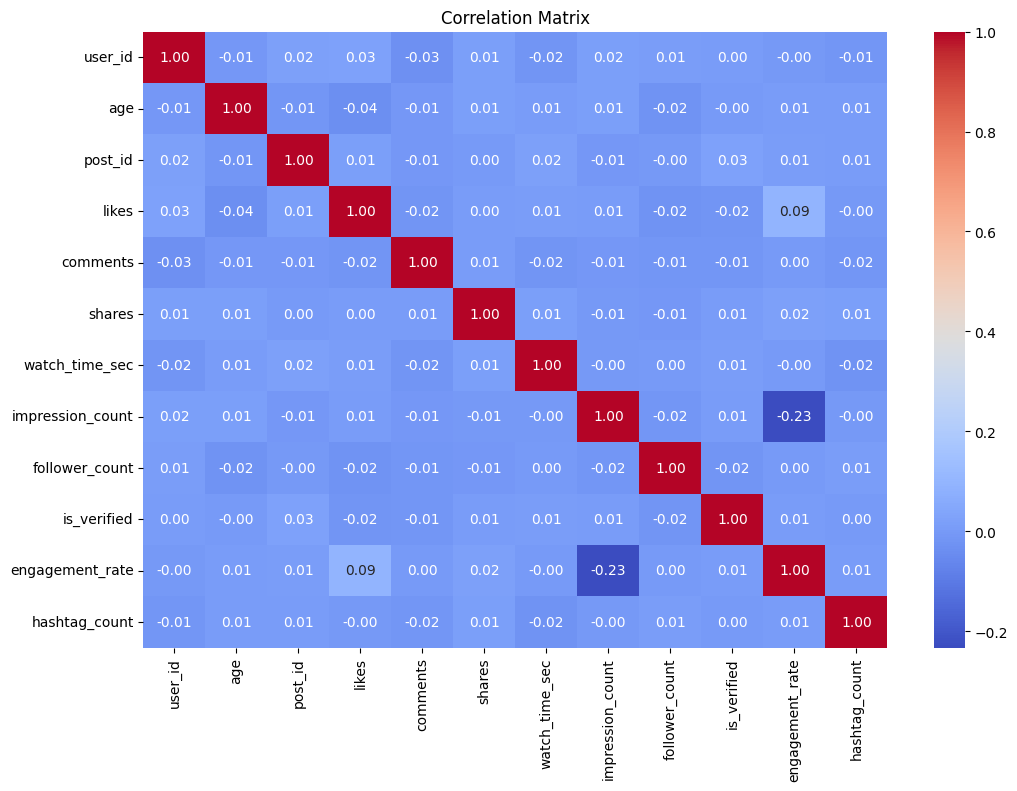

In [143]:
plt.figure(figsize=(12, 8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

Group By Analysis

In [144]:
avg_likes_by_post_type = df.groupby('post_type')['likes'].mean()

avg_likes_by_post_type

,likes
post_type,
image,10104.865277
reel,10037.802416
text,10100.148193
video,10188.600000


In [145]:
avg_impressions_by_country = df.groupby('country')['impression_count'].mean()

avg_impressions_by_country

,impression_count
country,
Australia,48346.383367
Brazil,49193.174603
Canada,48703.150097
France,51727.673387
Germany,48605.406122
India,52462.386916
Japan,49616.135593
UAE,48928.413519
UK,51119.393509


In [146]:
avg_engagement_by_sentiment = df.groupby('sentiment')['engagement_rate'].mean()

avg_engagement_by_sentiment

,engagement_rate
sentiment,
negative,1.038486
neutral,0.991170
positive,0.919744


4. DATA WRANGLING

In [147]:
# Create Engagement Score

df['engagement_score'] = df['likes'] + df['comments'] + df['shares']

In [148]:
df[['likes', 'comments', 'shares', 'engagement_score']].head()

,likes,comments,shares,engagement_score
0,7011.0,354.0,1157.0,8522.0
1,11750.0,2606.0,1807.0,16163.0
2,4862.0,344.0,955.0,6161.0
3,5350.0,1083.0,1049.0,7482.0
4,12682.0,2735.0,1300.0,16717.0


In [149]:
#  GroupBy Post Type

post_type_summary = df.groupby('post_type').agg({
    'likes': 'mean',
    'comments': 'mean',
    'shares': 'mean',
    'engagement_score': 'mean'
})

post_type_summary

,likes,comments,shares,engagement_score
post_type,,,,
image,10104.865277,1525.235766,1019.289495,12649.390537
reel,10037.802416,1504.187062,982.042089,12524.031567
text,10100.148193,1499.106024,1013.989558,12613.243775
video,10188.600000,1479.160000,996.834286,12664.594286


In [150]:
#  GroupBy Country

country_summary = df.groupby('country').agg({
    'impression_count': 'mean',
    'engagement_rate': 'mean'
})

country_summary

,impression_count,engagement_rate
country,,
Australia,48346.383367,1.324339
Brazil,49193.174603,1.540704
Canada,48703.150097,0.916659
France,51727.673387,1.146402
Germany,48605.406122,0.759000
India,52462.386916,0.655005
Japan,49616.135593,0.769623
UAE,48928.413519,1.112352
UK,51119.393509,0.850966


In [151]:
#  GroupBy Sentiment

sentiment_summary = df.groupby('sentiment').agg({
    'likes': 'mean',
    'comments': 'mean',
    'shares': 'mean',
    'engagement_rate': 'mean'
})

sentiment_summary

,likes,comments,shares,engagement_rate
sentiment,,,,
negative,10208.096875,1516.094792,1007.307292,1.038486
neutral,9923.194499,1528.404060,996.565160,0.991170
positive,10180.062077,1480.650617,1005.086749,0.919744


5. STATISTICAL ANALYSIS

In [152]:
numeric_columns = [
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'engagement_rate',
    'follower_count'
]

In [153]:
df[numeric_columns].mean()

,0
likes,10106.997400
comments,1502.039800
shares,1002.910600
watch_time_sec,4014.503200
engagement_rate,0.964356
follower_count,393698.224800


In [154]:
df[numeric_columns].median()

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000


In [155]:
df[numeric_columns].std()

,0
likes,5702.293017
comments,856.393312
shares,570.855200
watch_time_sec,2308.096459
engagement_rate,5.318029
follower_count,230927.884535


In [156]:
df[numeric_columns].var()

,0
likes,3.251615e+07
comments,7.334095e+05
shares,3.258757e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10


In [157]:
df[numeric_columns].quantile([0.25, 0.50, 0.75])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.145781,194480.00
0.50,10105.5,1497.00,1012.0,4034.50,0.253896,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25


In [158]:
df[numeric_columns].mode().iloc[0]

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,916.000000
engagement_rate,0.006363
follower_count,497502.000000


In [159]:
statistics_summary = pd.DataFrame({
    'Mean': df[numeric_columns].mean(),
    'Median': df[numeric_columns].median(),
    'Mode': df[numeric_columns].mode().iloc[0],
    'Standard Deviation': df[numeric_columns].std(),
    'Variance': df[numeric_columns].var(),
    '25th Percentile': df[numeric_columns].quantile(0.25),
    '50th Percentile': df[numeric_columns].quantile(0.50),
    '75th Percentile': df[numeric_columns].quantile(0.75)
})

statistics_summary

,Mean,Median,Mode,Standard Deviation,Variance,25th Percentile,50th Percentile,75th Percentile
likes,10106.997400,10105.500000,10105.500000,5702.293017,3.251615e+07,5235.000000,10105.500000,14959.000000
comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05,792.000000,1497.000000,2235.250000
shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05,511.000000,1012.000000,1483.000000
watch_time_sec,4014.503200,4034.500000,916.000000,2308.096459,5.327309e+06,2017.750000,4034.500000,6020.250000
engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01,0.145781,0.253896,0.504794
follower_count,393698.224800,388982.000000,497502.000000,230927.884535,5.332769e+10,194480.000000,388982.000000,589744.250000


6. DATA VISUALIZATION


6.1 MATPLOTLIB SCATTER PLOT

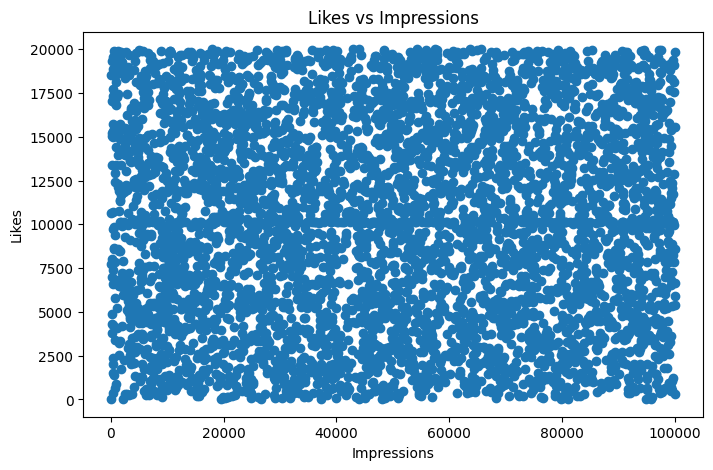

In [160]:
plt.figure(figsize=(8, 5))

plt.scatter(df['impression_count'], df['likes'])

plt.xlabel('Impressions')
plt.ylabel('Likes')
plt.title('Likes vs Impressions')

plt.show()

6.2 DAILY ENGAGEMENT TREND

In [161]:
daily_engagement = df.groupby('posted_at')['engagement_score'].mean()

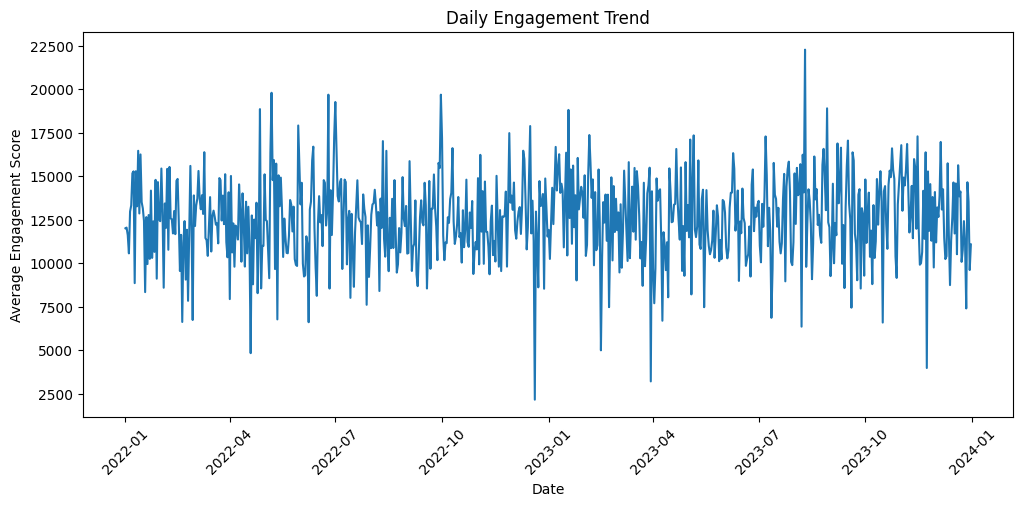

In [162]:
plt.figure(figsize=(12, 5))

plt.plot(daily_engagement.index, daily_engagement.values)

plt.xlabel('Date')
plt.ylabel('Average Engagement Score')
plt.title('Daily Engagement Trend')

plt.xticks(rotation=45)

plt.show()

6.3 POSTS BY CATEGORY

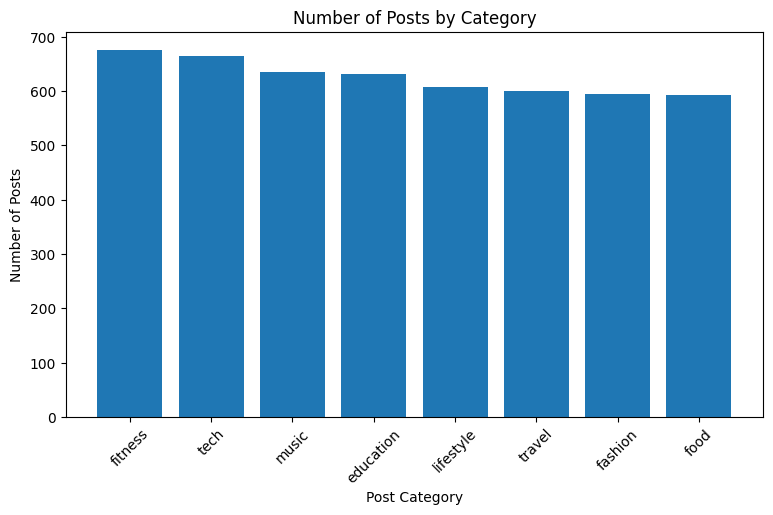

In [163]:
category_counts = df['post_category'].value_counts()

plt.figure(figsize=(9, 5))

plt.bar(category_counts.index, category_counts.values)

plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.title('Number of Posts by Category')

plt.xticks(rotation=45)

plt.show()

6.4 GENDER DISTRIBUTION

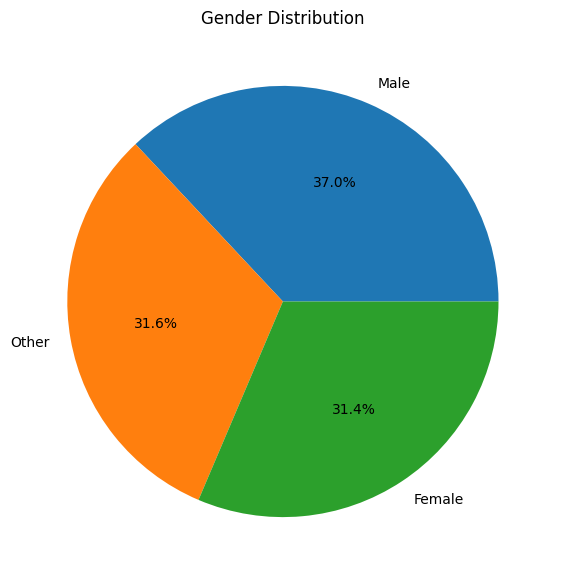

In [164]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title('Gender Distribution')

plt.show()

6.5 AGE DISTRIBUTION

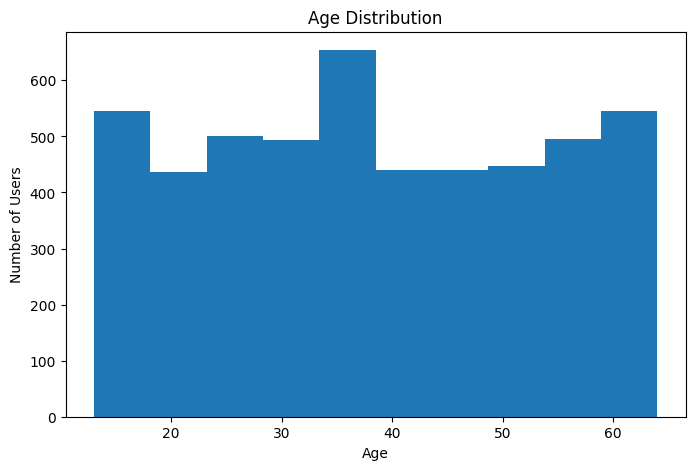

In [165]:
plt.figure(figsize=(8, 5))

plt.hist(df['age'], bins=10)

plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.title('Age Distribution')

plt.show()

6.6 ENGAGEMENT RATE BOX

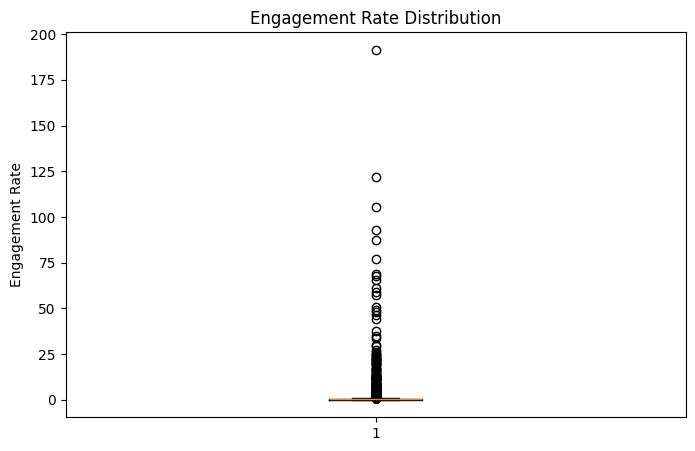

In [166]:
plt.figure(figsize=(8, 5))

plt.boxplot(df['engagement_rate'])

plt.ylabel('Engagement Rate')
plt.title('Engagement Rate Distribution')

plt.show()

Seaborn Plot 7 — Count Plot: Post Type

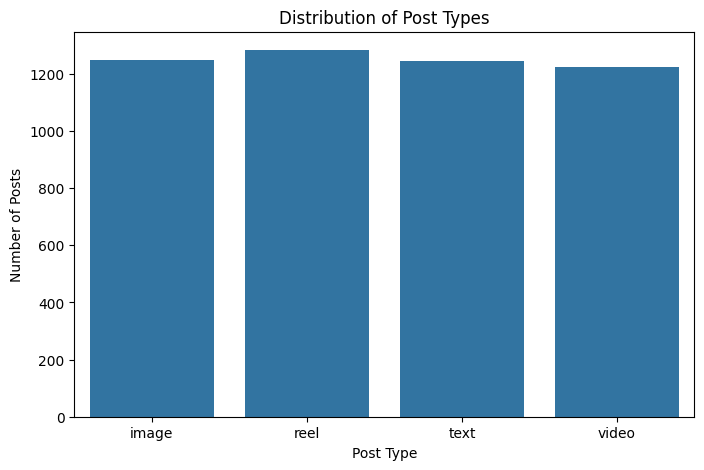

In [167]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='post_type')

plt.xlabel('Post Type')
plt.ylabel('Number of Posts')
plt.title('Distribution of Post Types')

plt.show()

Seaborn Plot 8 — Average Likes by Category

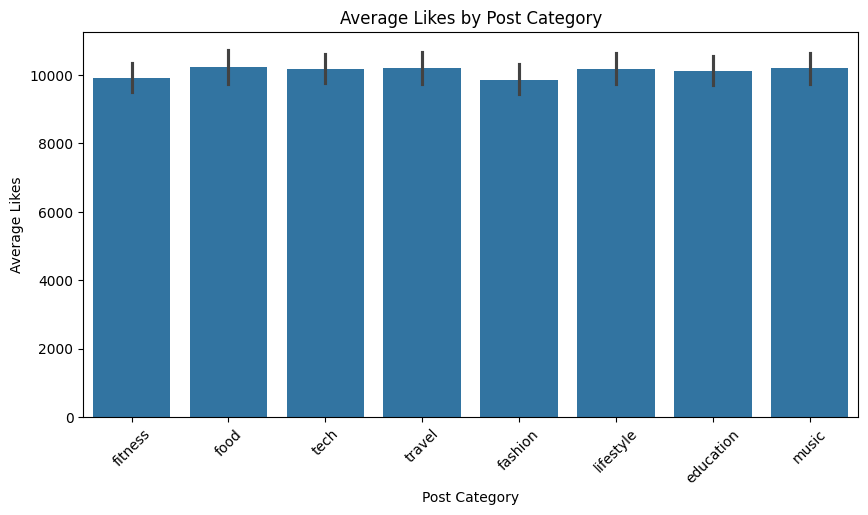

In [168]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x='post_category',
    y='likes'
)

plt.xlabel('Post Category')
plt.ylabel('Average Likes')
plt.title('Average Likes by Post Category')

plt.xticks(rotation=45)

plt.show()

Seaborn Plot 9 — Violin Plot: Followers vs Sentiment

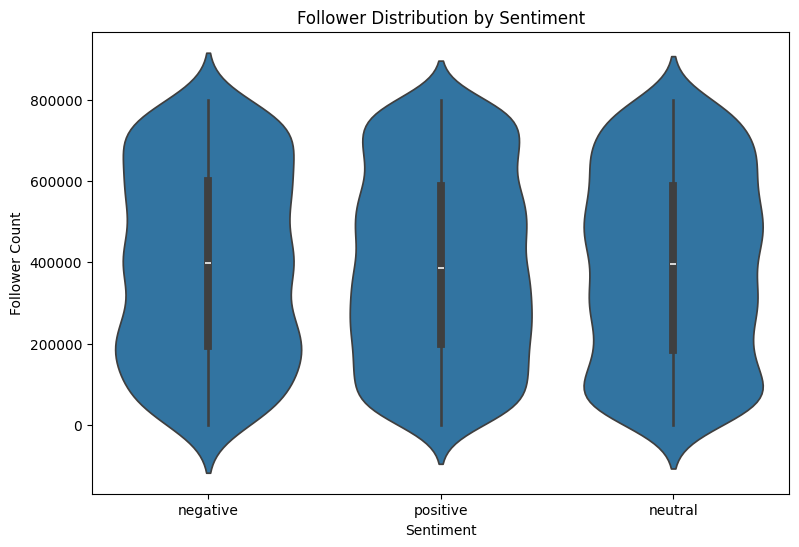

In [169]:
plt.figure(figsize=(9, 6))

sns.violinplot(
    data=df,
    x='sentiment',
    y='follower_count'
)

plt.xlabel('Sentiment')
plt.ylabel('Follower Count')
plt.title('Follower Distribution by Sentiment')

plt.show()

Seaborn Plot 10 — Correlation Heatmap

In [170]:
correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,0.004058,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,-0.000079,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.025208,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,-0.016200,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,-0.012398,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.007025,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,0.012326,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,0.008317,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,-0.017808,0.002292,0.008802
is_verified,0.004058,-0.000079,0.025208,-0.016200,-0.012398,0.007025,0.012326,0.008317,-0.017808,1.000000,0.005528,0.001396


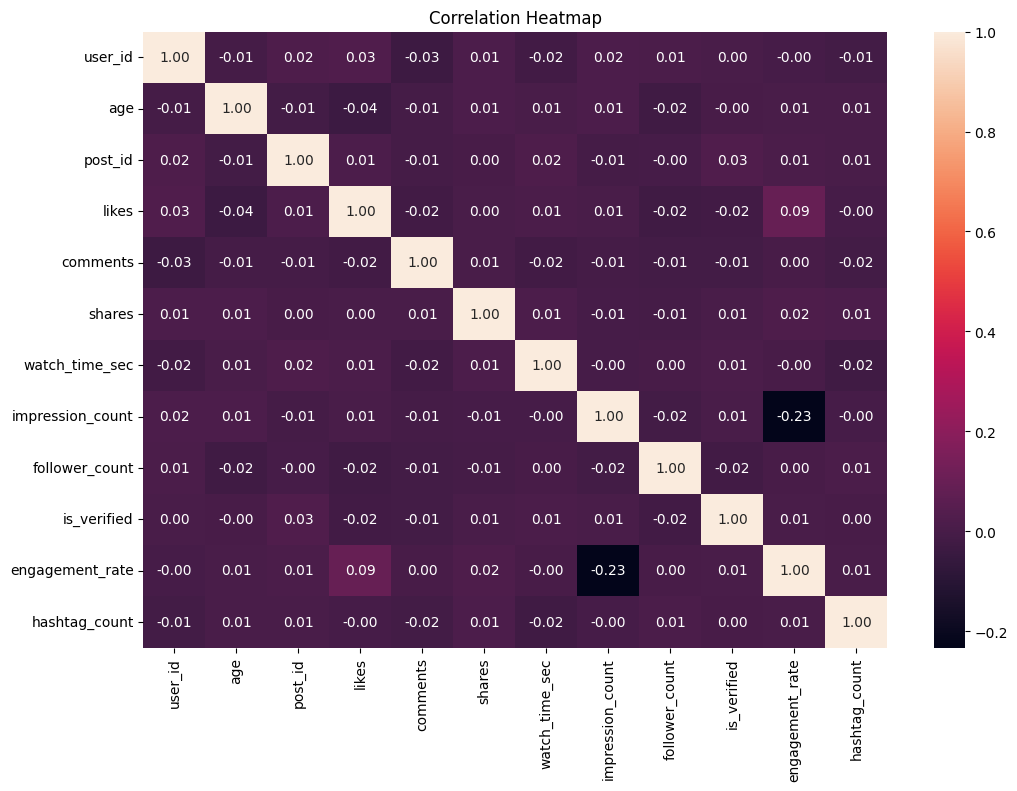

In [171]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

11. PLOTY INTERACTIVE VISUALIZATION


In [172]:
fig = px.scatter(
    df,
    x='impression_count',
    y='engagement_score',
    title='Impressions vs Engagement Score',
    labels={
        'impression_count': 'Impressions',
        'engagement_score': 'Engagement Score'
    },
    hover_data=['post_type', 'post_category', 'sentiment']
)

fig.show()

7. FINAL BUSINESS ANALYSIS

In [173]:
#  POST TYPE PERFORMANCE

post_type_performance = df.groupby('post_type').agg({
    'engagement_score': 'mean',
    'engagement_rate': 'mean',
    'likes': 'mean',
    'comments': 'mean',
    'shares': 'mean'
})

post_type_performance

,engagement_score,engagement_rate,likes,comments,shares
post_type,,,,,
image,12649.390537,0.895646,10104.865277,1525.235766,1019.289495
reel,12524.031567,0.783047,10037.802416,1504.187062,982.042089
text,12613.243775,1.064549,10100.148193,1499.106024,1013.989558
video,12664.594286,1.122365,10188.600000,1479.160000,996.834286


In [174]:
#  CATEGORY PERFORMANCE

category_performance = df.groupby('post_category').agg({
    'engagement_score': 'mean',
    'engagement_rate': 'mean',
    'likes': 'mean'
}).sort_values('engagement_rate', ascending=False)

category_performance

,engagement_score,engagement_rate,likes
post_category,,,
food,12739.200675,1.358628,10225.522766
tech,12686.490226,1.160475,10171.571429
lifestyle,12639.539539,1.091019,10180.559308
music,12788.549606,0.888803,10205.749606
fitness,12457.791852,0.865628,9914.602222
education,12578.270206,0.844222,10126.487322
fashion,12356.420875,0.807109,9843.356902
travel,12650.559167,0.702223,10196.304167


In [175]:
#  VERIFIED VS UNVERIFIED

verification_performance = df.groupby('is_verified').agg({
    'engagement_score': 'mean',
    'engagement_rate': 'mean',
    'likes': 'mean',
    'impression_count': 'mean'
})

verification_performance

,engagement_score,engagement_rate,likes,impression_count
is_verified,,,,
False,12644.311822,0.954744,10137.201129,49935.288244
True,12309.280538,1.054250,9824.533126,50747.343685


In [176]:
#  AGE AND ENGAGEMENT

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 25, 35, 45, 55, 100],
    labels=['Under 18', '18-25', '26-35', '36-45', '46-55', '56+']
)

In [177]:
age_performance = df.groupby('age_group', observed=True).agg({
    'engagement_rate': 'mean',
    'engagement_score': 'mean',
    'impression_count': 'mean'
})

age_performance

,engagement_rate,engagement_score,impression_count
age_group,,,
Under 18,0.867038,12991.711538,49225.637363
18-25,1.059536,12628.408385,49254.684783
26-35,0.865316,12768.703874,49864.082569
36-45,0.860741,12741.579461,50847.114312
46-55,1.414058,12373.489663,49475.526659
56+,0.709213,12261.744005,50809.688249


In [178]:
#  BEST TIME OF DAY FOR IMPRESSIONS

df['hour'] = df['posted_at'].dt.hour

In [179]:
def get_time_of_day(hour):
    if hour < 6:
        return 'Night'
    elif hour < 12:
        return 'Morning'
    elif hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

In [183]:
df['hour'].value_counts().sort_index()

,count
hour,
0,5000


In [189]:
# DEVICE TYPE VS WATCH TIME

device_performance = df.groupby('device_type').agg({
    'watch_time_sec': 'mean',
    'engagement_rate': 'mean',
    'engagement_score': 'mean'
}).sort_values('watch_time_sec', ascending=False)

device_performance

,watch_time_sec,engagement_rate,engagement_score
device_type,,,
mobile,4087.830760,1.123999,12663.194477
tablet,3979.736429,0.804560,12463.280458
desktop,3974.792521,0.962006,12708.564837


In [188]:
df['engagement_rate'].sort_values(ascending=False).head(10)

,engagement_rate
554,191.504348
144,121.931973
1947,105.752212
541,92.828829
145,87.266094
4181,77.160173
2369,68.685897
2426,67.511041
652,65.580247
2993,61.179775


In [186]:
df[['engagement_rate', 'likes', 'comments', 'shares', 'impression_count']].sort_values(
    'engagement_rate',
    ascending=False
).head(10)

,engagement_rate,likes,comments,shares,impression_count
554,191.504348,18513.0,2090.0,1420.0,115
144,121.931973,15055.0,1253.0,1616.0,147
1947,105.752212,10652.0,409.0,889.0,113
541,92.828829,7736.0,1681.0,887.0,111
145,87.266094,19311.0,415.0,607.0,233
4181,77.160173,17045.0,688.0,91.0,231
2369,68.685897,8044.0,864.0,1807.0,156
2426,67.511041,17338.0,2580.0,1483.0,317
652,65.580247,13410.0,2117.0,409.0,243
2993,61.179775,6996.0,2972.0,922.0,178


In [185]:
statistics_summary

,Mean,Median,Mode,Standard Deviation,Variance,25th Percentile,50th Percentile,75th Percentile
likes,10106.997400,10105.500000,10105.500000,5702.293017,3.251615e+07,5235.000000,10105.500000,14959.000000
comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05,792.000000,1497.000000,2235.250000
shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05,511.000000,1012.000000,1483.000000
watch_time_sec,4014.503200,4034.500000,916.000000,2308.096459,5.327309e+06,2017.750000,4034.500000,6020.250000
engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01,0.145781,0.253896,0.504794
follower_count,393698.224800,388982.000000,497502.000000,230927.884535,5.332769e+10,194480.000000,388982.000000,589744.250000


# Final Insights and Findings

## 1. Content Performance

- Among the post types, video posts recorded the highest average engagement score (12,664.59) and the highest average engagement rate (1.122).
- Food was the highest-performing content category based on average engagement rate (1.359), while music recorded the highest average engagement score (12,788.55).
- India had the highest average impression count (52,462), while Brazil recorded the highest average engagement rate (1.541).

## 2. User Trends

- The 46–55 age group recorded the highest average engagement rate (1.414).
- The 56+ age group recorded the lowest average engagement rate (0.709).
- Verified accounts had a higher average engagement rate (1.054) than unverified accounts (0.955).
- Verified accounts also had slightly higher average impressions (50,747) compared with unverified accounts (49,935).

## 3. Behavioral Insights

- Mobile users recorded the highest average watch time at approximately 4,088 seconds.
- Mobile users also had the highest average engagement rate (1.124).
- Desktop users recorded the highest average engagement score (12,708.56).
- Time-of-day performance could not be reliably analyzed because the dataset contains dates but does not contain actual posting-time information. All converted timestamps have an hour value of 0.

## 4. Sentiment Analysis

- Positive sentiment was the most common sentiment, with 2,513 posts, followed by neutral sentiment with 1,527 posts and negative sentiment with 960 posts.
- Negative-sentiment posts recorded the highest average engagement rate (1.038).
- Neutral posts recorded an average engagement rate of 0.991, while positive posts recorded 0.920.

## 5. Statistical Findings

- Likes, comments and shares have means relatively close to their medians, although the engagement metrics show some variation.
- Engagement rate has a substantial spread, with a mean of approximately 0.964 and a median of approximately 0.254.
- Very high engagement-rate values were investigated and were found to correspond to posts with relatively low impression counts. Therefore, these observations were retained rather than removed as errors.

## Overall Summary

The analysis shows that engagement varies across post types, content categories, countries, age groups, account verification status, devices and sentiment. Video posts performed strongly on both engagement score and engagement rate, while food content had the highest average engagement rate. Brazil recorded the highest average engagement rate among countries, whereas India recorded the highest average impressions. Negative-sentiment posts had higher average engagement rates than positive and neutral posts. Mobile users showed the highest average watch time and engagement rate. However, the dataset does not contain actual posting times, so time-of-day performance could not be determined reliably.